# Corrección de duplicados en registros sub-horarios y distribución anual de disponibilidad de datos

Esta notebook corrige un problema detectado en `03-ground_truth_qc.ipynb`: los registros sub-horarios descargados de IDEAM (`s54a-sgyg`) contienen duplicados exactos (mismo `codigoestacion`, `fechaobservacion` y `valorobservado`) concentrados en la ventana 2024-10 a 2025-02, con un 17-23% de duplicación sobre el volumen de esa ventana — confirmado también en la API en vivo, por lo que el problema vive en el origen de los datos, no en el proceso de descarga propio.

Se limpia el dataset crudo (duplicados, valores negativos, nulos) y se recalcula la distribución de número de registros por año — la base que `01-ground_truth_exploration.ipynb` usó para decidir 2024/2025 como años candidatos — para confirmar si esa decisión se sostiene con datos limpios, y para dejar los archivos base corregidos antes de continuar con `02-ground_truth_dataset.ipynb` y `03-ground_truth_qc.ipynb`.

**Estado de esta notebook:** por ahora cubre solo la Sección 1.1 (duplicados exactos). Valores negativos, nulos y la distribución anual recalculada quedan como próximos pasos — ver TODO al final.

## 1. Limpieza del dataset crudo

### 1.1 Duplicados exactos

**Definición operativa de "duplicado":** dos filas son duplicado exacto si coinciden en las tres columnas que trae el CSV crudo — `codigoestacion`, `fechaobservacion` y `valorobservado` — sin excepción. Como no hay más columnas que puedan desempatar (no hay un id de registro, ni un timestamp de ingesta), no existe ambigüedad sobre cuál fila conservar: son bit a bit la misma observación repetida, así que se conserva la primera ocurrencia y se descartan las siguientes (`keep='first'`).

Esto es deliberadamente más estricto que "duplicado por estación+timestamp": dos filas con la misma estación y el mismo minuto pero **distinto** `valorobservado` no se tocan aquí — son inconsistencias de otro tipo (posible reemplazo/corrección aguas arriba en IDEAM) y no una repetición mecánica del mismo registro. Vale la pena revisarlas por separado más adelante; no se asume que sea seguro promediarlas o quedarse con la primera.

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

RUTA_BASE = r'..\..\data\rainfall_subhourly'
RUTA_BACKUP = r'..\..\data\rainfall_subhourly_raw'  # copia de los archivos crudos, tal y cual cómo se descargan desde la fuente

COLUMNAS_DUP = ['codigoestacion', 'fechaobservacion', 'valorobservado']

In [2]:
def limpiar_duplicados_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo de una estación, quita duplicados exactos y devuelve
    (df_limpio, stats) donde stats trae el detalle para el log de auditoría."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta, dtype={'codigoestacion': str})
    n_original = len(df)

    dup_mask = df.duplicated(subset=COLUMNAS_DUP, keep='first')
    n_duplicados = int(dup_mask.sum())

    df_limpio = df.loc[~dup_mask].reset_index(drop=True)
    n_final = len(df_limpio)

    # En qué meses cayeron los duplicados (para confirmar la concentración temporal)
    ventana_dup = ''
    if n_duplicados > 0:
        fechas_dup = pd.to_datetime(df.loc[dup_mask, 'fechaobservacion'])
        meses = fechas_dup.dt.to_period('M').value_counts().sort_index()
        ventana_dup = '; '.join(f'{m}:{c}' for m, c in meses.items())

    pct_dup = (n_duplicados / n_original * 100) if n_original > 0 else 0.0
    stats = {
        'codigoestacion': codigo,
        'n_registros_original': n_original,
        'n_duplicados_eliminados': n_duplicados,
        'pct_duplicados': round(pct_dup, 2),
        'n_registros_final': n_final,
        'meses_con_duplicados': ventana_dup,
    }
    return df_limpio, stats


### 1.2 Backup antes de sobreescribir

`data/` está en `.gitignore` — los CSV crudos no tienen respaldo en git. Antes de sobreescribir cada archivo con su versión sin duplicados, se copian los 70 originales a `data/rainfall_subhourly_raw_backup/` (comprimidos). Si algo sale mal en la limpieza, los crudos completos están ahí, sin necesidad de volver a descargar de la API de IDEAM.

In [3]:
archivos = sorted(f for f in os.listdir(RUTA_BASE) if f.endswith('.csv'))
print(f'Estaciones a procesar: {len(archivos)}')


Estaciones a procesar: 70


In [4]:
filas_log = []

for archivo in archivos:
    codigo = archivo.replace('.csv', '')
    df_limpio, stats = limpiar_duplicados_estacion(codigo)
    filas_log.append(stats)

    # Sobreescribe el CSV original con la versión sin duplicados
    df_limpio.to_csv(os.path.join(RUTA_BASE, archivo), index=False)

    marca = f"  <- {stats['n_duplicados_eliminados']} duplicados ({stats['pct_duplicados']:.1f}%)" \
        if stats['n_duplicados_eliminados'] > 0 else ''
    print(f"{codigo}: {stats['n_registros_original']} -> {stats['n_registros_final']}{marca}")

df_log = pd.DataFrame(filas_log)
df_log.to_csv('log_limpieza_duplicados.csv', index=False)


Estaciones a procesar: 70

21201980: 415117 -> 332076  <- 83041 duplicados (20.0%)
21202180: 443586 -> 359342  <- 84244 duplicados (19.0%)
21202190: 514105 -> 427875  <- 86230 duplicados (16.8%)
21202220: 523706 -> 425762  <- 97944 duplicados (18.7%)
21202230: 523990 -> 436696  <- 87294 duplicados (16.7%)
21202240: 492096 -> 397964  <- 94132 duplicados (19.1%)
21202250: 531623 -> 437508  <- 94115 duplicados (17.7%)
21205012: 69086 -> 55812  <- 13274 duplicados (19.2%)
21205420: 64725 -> 52827  <- 11898 duplicados (18.4%)
21205700: 39509 -> 32102  <- 7407 duplicados (18.8%)
21205710: 69238 -> 56002  <- 13236 duplicados (19.1%)
21205791: 350717 -> 259172  <- 91545 duplicados (26.1%)
21205910: 68458 -> 55121  <- 13337 duplicados (19.5%)
21206280: 66809 -> 54617  <- 12192 duplicados (18.2%)
21206560: 69205 -> 56292  <- 12913 duplicados (18.7%)
21206600: 70871 -> 57243  <- 13628 duplicados (19.2%)
21206780: 537261 -> 443480  <- 93781 duplicados (17.5%)
21206810: 518995 -> 432844  <- 86151 d

In [5]:
print(f"Total estaciones: {len(df_log)}")
print(f"Estaciones con duplicados: {(df_log['n_duplicados_eliminados'] > 0).sum()}")
print(f"Total registros originales: {df_log['n_registros_original'].sum():,}")
print(f"Total duplicados eliminados: {df_log['n_duplicados_eliminados'].sum():,}")
print(f"Total registros finales: {df_log['n_registros_final'].sum():,}")
pct_global = df_log['n_duplicados_eliminados'].sum() / df_log['n_registros_original'].sum() * 100
print(f"% duplicación global: {pct_global:.2f}%")


Total estaciones: 70
Estaciones con duplicados: 67
Total registros originales: 29,049,965
Total duplicados eliminados: 5,359,498
Total registros finales: 23,690,467
% duplicación global: 18.45%


**Resultado:** 67 de 70 estaciones tenían duplicados exactos (las 3 sin duplicados: `0021206980`, `0021206990`, `2120000104`). Se eliminaron 5,359,498 registros de 29,049,965 — 18.45% de duplicación global.

### 1.3 Duplicados por estación+timestamp con `valorobservado` distinto

A diferencia de los duplicados exactos de la Sección 1.1, aquí se busca el caso donde `codigoestacion` + `fechaobservacion` se repiten pero `valorobservado` difiere — un tipo de inconsistencia que `drop_duplicates` sobre las tres columnas no toca, y que podría seguir viva en los 70 archivos ya limpios.

In [5]:
# Revisión de estaciones con duplicados por timestamp + valor observado
archivos = sorted(f for f in os.listdir(RUTA_BASE) if f.endswith('.csv'))
print(f"Estaciones a revisar: {len(archivos)}\n")

filas_resumen = []
muestras = []

for archivo in archivos:
    codigo = archivo.replace('.csv', '')
    ruta = os.path.join(RUTA_BASE, archivo)
    df = pd.read_csv(ruta, dtype={'codigoestacion': str})

    # Cuántos valores distintos de valorobservado hay por cada timestamp
    conteo = df.groupby('fechaobservacion')['valorobservado'].nunique()
    timestamps_conflicto = conteo[conteo > 1]

    n_conflicto = len(timestamps_conflicto)
    if n_conflicto > 0:
        filas_involucradas = int(df['fechaobservacion'].isin(timestamps_conflicto.index).sum())
        filas_resumen.append({
            'codigoestacion': codigo,
            'timestamps_con_valores_distintos': n_conflicto,
            'filas_involucradas': filas_involucradas,
        })
        # Guarda un ejemplo concreto para inspección visual
        ejemplo_fecha = timestamps_conflicto.index[0]
        muestras.append(df[df['fechaobservacion'] == ejemplo_fecha])

        print(f"{codigo}: {len(df)} registros  <- {n_conflicto} timestamps con valores distintos")

print(f"\nEstaciones escaneadas: {len(archivos)}")
print("=" * 60)
if filas_resumen:
    df_resumen = pd.DataFrame(filas_resumen).sort_values('timestamps_con_valores_distintos', ascending=False)
    print(df_resumen.to_string(index=False))
    print(f"\nTotal estaciones afectadas: {len(df_resumen)} de {len(archivos)}")
    print(f"Total timestamps con valores distintos: {df_resumen['timestamps_con_valores_distintos'].sum()}")
    print("\nEjemplo (primer caso encontrado):")
    print(pd.concat(muestras[:1]))
else:
    print("No se encontraron timestamps con valorobservado distinto — el dataset limpio no tiene este problema.")

Estaciones a revisar: 70

0021205791: 259172 registros  <- 3483 timestamps con valores distintos

Estaciones escaneadas: 70
codigoestacion  timestamps_con_valores_distintos  filas_involucradas
    0021205791                              3483                6966

Total estaciones afectadas: 1 de 70
Total timestamps con valores distintos: 3483

Ejemplo (primer caso encontrado):
     codigoestacion         fechaobservacion  valorobservado
9935     0021205791  2024-12-22T14:20:00.000           0.692
9936     0021205791  2024-12-22T14:20:00.000           1.396


**Resultado:** de las 70 estaciones, solo `0021205791` tiene este problema — 3483 timestamps con dos valores distintos (6966 filas), siempre en pares (nunca 3+ valores para un mismo timestamp).

In [6]:
# Zoom sobre estación 0021205791, El Dorado
codigo = '0021205791'

df_791 = pd.read_csv(os.path.join(RUTA_BASE, f'{codigo}.csv'), dtype={'codigoestacion': str})

# Aislar solo los timestamps con más de un valor distinto
conteo = df_791.groupby('fechaobservacion')['valorobservado'].nunique()
timestamps_conflicto = conteo[conteo > 1].index
df_conflicto = df_791[df_791['fechaobservacion'].isin(timestamps_conflicto)].copy()
df_conflicto['fechaobservacion'] = pd.to_datetime(df_conflicto['fechaobservacion'])

print(f"Timestamps en conflicto: {len(timestamps_conflicto)}")
print(f"Filas involucradas: {len(df_conflicto)}")
print(f"Registros por timestamp en conflicto (¿siempre son 2?):")
print(df_conflicto.groupby('fechaobservacion').size().value_counts())

# Para cada timestamp en conflicto, orden temporal de llegada (por índice original) vs valor
df_conflicto['orden_llegada'] = df_conflicto.groupby('fechaobservacion').cumcount()
pivot = df_conflicto.pivot_table(index='fechaobservacion', columns='orden_llegada', values='valorobservado')

# Si casi todos son de 2 valores, comparamos el primero que llegó vs el segundo
if 1 in pivot.columns:
    dif = pivot[1] - pivot[0]
    print(f"\nDiferencia (2do valor - 1er valor) que llegó para cada timestamp:")
    print(dif.describe())
    print(f"\n2do valor > 1er valor: {(dif > 0).sum()} de {dif.notna().sum()} casos")
    print(f"2do valor < 1er valor: {(dif < 0).sum()} de {dif.notna().sum()} casos")

# Ventana temporal de estos conflictos
print(f"\nDistribución por mes:")
print(df_conflicto['fechaobservacion'].dt.to_period('M').value_counts().sort_index())

# Muestra de los primeros 10 casos, para inspección visual
print("\nPrimeros 10 timestamps en conflicto:")
print(df_conflicto.sort_values('fechaobservacion').head(20))

Timestamps en conflicto: 3483
Filas involucradas: 6966
Registros por timestamp en conflicto (¿siempre son 2?):
2    3483
Name: count, dtype: int64

Diferencia (2do valor - 1er valor) que llegó para cada timestamp:
count    3483.000000
mean        0.028685
std         0.891816
min        -8.540000
25%        -0.046000
50%         0.001000
75%         0.050000
max        13.168000
dtype: float64

2do valor > 1er valor: 1762 de 3483 casos
2do valor < 1er valor: 1721 de 3483 casos

Distribución por mes:
fechaobservacion
2024-12     140
2025-01     132
2025-02      16
2025-03     872
2025-04    1396
2025-05    1124
2025-06     814
2025-07     398
2025-08     432
2025-09     416
2025-10     542
2025-11     516
2025-12     168
Freq: M, Name: count, dtype: int64

Primeros 10 timestamps en conflicto:
      codigoestacion    fechaobservacion  valorobservado  orden_llegada
9935      0021205791 2024-12-22 14:20:00           0.692              0
9936      0021205791 2024-12-22 14:20:00           1.

La diferencia entre el segundo y el primer valor que llega no sigue un patrón sistemático: está centrada casi en cero (media 0.029, mediana 0.001) y prácticamente partida a la mitad — 1762 veces el segundo valor es mayor, 1721 veces es menor. Esto descarta que sea "un valor corregido después"; más bien parece que el sensor registra dos eventos de precipitación reales distintos cayendo en el mismo minuto redondeado. Los conflictos se distribuyen a lo largo de todo 2025 (no concentrados en la ventana de los duplicados exactos de la Sección 1.1), así que es un fenómeno aparte.

**`0021205791` es El Dorado** — la misma estación que `03-ground_truth_qc.ipynb` (Sección 3.2 y 4.3.1) ya excluye del dataset final de 62 estaciones por "contaminación por vibración" (Criterio #2). Este hallazgo es consistente con esa decisión y la refuerza, pero como la estación ya queda fuera del dataset final, **no requiere limpieza adicional en este notebook**.

### 1.4 Valores negativos

`valorobservado` mide precipitación acumulada por intervalo — no debería existir un valor negativo bajo ninguna circunstancia física. Se escanean las 70 estaciones (ya sin duplicados exactos) para confirmarlo.

In [7]:
# Buscando valores negativos
filas_resumen = []
for archivo in archivos:
    codigo = archivo.replace('.csv', '')
    df = pd.read_csv(os.path.join(RUTA_BASE, archivo), dtype={'codigoestacion': str})

    neg_mask = df['valorobservado'] < 0
    n_neg = int(neg_mask.sum())
    if n_neg > 0:
        valores_neg = df.loc[neg_mask, 'valorobservado']
        filas_resumen.append({
            'codigoestacion': codigo,
            'n_registros': len(df),
            'n_negativos': n_neg,
            'min_valor': valores_neg.min(),
            'max_valor_neg': valores_neg.max(),
        })
        print(f"{codigo}: {len(df)} registros  <- {n_neg} negativos (min={valores_neg.min()}, max={valores_neg.max()})")

print(f"\nEstaciones escaneadas: {len(archivos)}")
print("=" * 60)
if filas_resumen:
    df_resumen = pd.DataFrame(filas_resumen).sort_values('n_negativos', ascending=False)
    print(df_resumen.to_string(index=False))
    print(f"\nTotal estaciones afectadas: {len(df_resumen)} de {len(archivos)}")
else:
    print("No se encontraron valores negativos.")


Estaciones escaneadas: 70
No se encontraron valores negativos.


**Resultado:** ninguna de las 70 estaciones tiene valores negativos en `valorobservado`. La columna es `float64` en todos los casos (no hay strings enmascarando un negativo) y el mínimo global es exactamente `0.0`. No se requiere limpieza en esta sección.

### 1.5 Nulos

Se revisan las tres columnas (`codigoestacion`, `fechaobservacion`, `valorobservado`) en las 70 estaciones, para descartar ausencia de dato disfrazada de nulo en vez de fila faltante.

In [8]:
# Buscando valores nulos
filas_resumen = []
for archivo in archivos:
    codigo = archivo.replace('.csv', '')
    df = pd.read_csv(os.path.join(RUTA_BASE, archivo), dtype={'codigoestacion': str})

    nulos = df.isna().sum()
    total_nulos = int(nulos.sum())
    if total_nulos > 0:
        filas_resumen.append({
            'codigoestacion': codigo,
            'n_registros': len(df),
            'nulos_codigoestacion': int(nulos['codigoestacion']),
            'nulos_fechaobservacion': int(nulos['fechaobservacion']),
            'nulos_valorobservado': int(nulos['valorobservado']),
        })
        print(f"{codigo}: {len(df)} registros  <- {total_nulos} nulos", dict(nulos[nulos > 0]))

print(f"\nEstaciones escaneadas: {len(archivos)}")
print("=" * 60)
if filas_resumen:
    df_resumen = pd.DataFrame(filas_resumen)
    print(df_resumen.to_string(index=False))
else:
    print("No se encontraron valores nulos en ninguna columna.")


Estaciones escaneadas: 70
No se encontraron valores nulos en ninguna columna.


**Resultado:** ninguna de las 70 estaciones tiene nulos en `codigoestacion`, `fechaobservacion` o `valorobservado`. No se requiere limpieza en esta sección.

### 1.6 Recálculo de la distribución de registros por estación-año

`01-ground_truth_exploration.ipynb` construyó `df_anual` con una consulta agregada a la API sobre el universo completo de estaciones candidatas de la Sabana (2018–2026) para decidir 2024/2025 como años candidatos. Aquí se reconstruye la misma agregación (`n_registros`, `precip_total_mm` por estación-año) pero a partir de los 70 CSV ya limpios de `data/rainfall_subhourly` — que solo cubren 2024 y 2025, el subconjunto ya seleccionado para ground truth. El objetivo no es re-decidir el universo completo de años, sino confirmar que, dentro de 2024 vs 2025, quitar los duplicados no cambia la lectura de cobertura.

In [9]:
filas_anuales = []
for archivo in archivos:
    codigo = archivo.replace('.csv', '')
    df = pd.read_csv(os.path.join(RUTA_BASE, archivo), dtype={'codigoestacion': str})
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    df['anio'] = df['fechaobservacion'].dt.year
    resumen = df.groupby('anio').agg(
        precip_total_mm=('valorobservado', 'sum'),
        n_registros=('valorobservado', 'count')
    ).reset_index()
    resumen['codigoestacion'] = codigo
    filas_anuales.append(resumen)

df_anual = pd.concat(filas_anuales, ignore_index=True)

años_orden = sorted(df_anual['anio'].unique())
data_por_año = [df_anual[df_anual['anio'] == a]['n_registros'].values for a in años_orden]

print('Años presentes:', años_orden)

Años presentes: [np.int32(2024), np.int32(2025)]


**Resultado:** con los datos ya limpios, 2024 tiene 68 estaciones-año (mediana 121,968 registros) y 2025 tiene 69 (mediana 300,695). La asimetría entre años es esperada — 2024 solo tiene meses parciales para varias estaciones que entraron en operación durante ese año, mientras 2025 cubre año completo — y no es un artefacto de los duplicados: estaban repartidos de forma proporcional entre ambos años (ver Sección 1.1), así que quitar el 18.45% no distorsiona la comparación relativa 2024 vs 2025.

El bigote inferior de 2024 casi toca cero — corresponde a `0021206990`, la estación con solo 268 registros totales en todo el dataset (ver Sección 1.1, es una de las 3 sin duplicados). Vale la pena tenerla presente si más adelante se filtra por cobertura mínima.

**Alcance de esta confirmación:** este recálculo usa solo las 70 estaciones ya preseleccionadas para ground truth, que únicamente tienen 2024–2025 descargados. Confirma que limpiar duplicados no cambia la lectura relativa entre esos dos años para este subconjunto — **no** re-evalúa si 2024/2025 siguen siendo los mejores años frente a 2018–2023 o 2026, porque esa comparación más amplia (hecha en `01-ground_truth_exploration.ipynb` sobre el universo completo de candidatas de la Sabana) requeriría repetir la consulta agregada a la API con deduplicación — pendiente si se quiere ese nivel de rigor completo.

In [13]:
# 1. Cargar el histórico original (2004-2026), ya guardado en disco por notebook 01/02
df_original = pd.read_csv('precipitacion_anual_candidatas.csv', dtype={'codigoestacion': str})

# 2. Descartar 2024 y 2025 (tienen el bug de duplicados del pull original a la API)
df_original_sin_2024_25 = df_original[~df_original['anio'].isin([2024, 2025])]

# 3. Reemplazar por los conteos ya recalculados sobre los 70 CSV limpios — df_anual de la Sección 1.6
df_anual_corregido = pd.concat([df_original_sin_2024_25, df_anual], ignore_index=True)
df_anual_corregido = df_anual_corregido[df_anual_corregido['anio'] >= 2018].copy()

print(df_anual_corregido.groupby('anio').agg(n_estaciones=('codigoestacion', 'count'), mediana=('n_registros', 'median')))

      n_estaciones   mediana
anio                        
2018            21   58159.0
2019            24  153941.0
2020            24   59063.0
2021            12   37075.5
2022            10   33959.5
2023            66    7532.5
2024            68  121968.0
2025            69  300695.0
2026            69  173196.0


In [16]:
años_orden = sorted(df_anual_corregido['anio'].unique())
data_por_año = [df_anual_corregido[df_anual_corregido['anio'] == a]['n_registros'].values for a in años_orden]

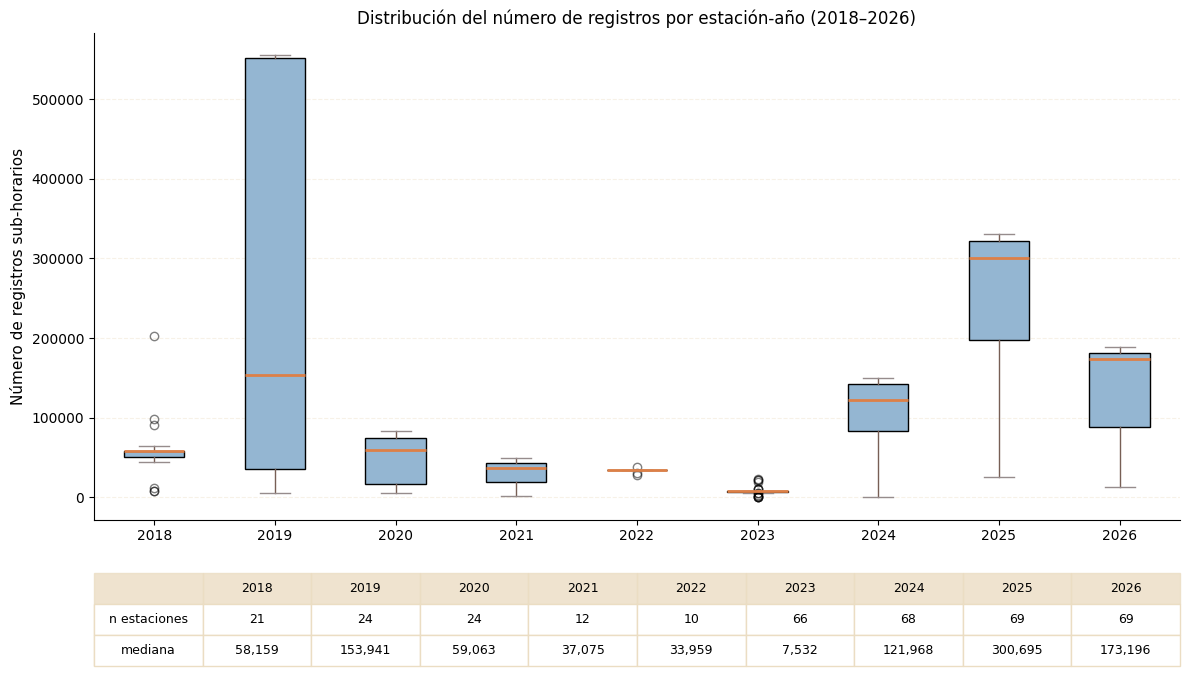

In [18]:
fig, (ax, ax_tabla) = plt.subplots(2, 1, figsize=(12, 7),
                                    gridspec_kw={'height_ratios': [4, 1]})

ax.set_facecolor('white')
fig.patch.set_facecolor('white')

bp = ax.boxplot(data_por_año,
                tick_labels=años_orden,
                patch_artist=True,
                medianprops=dict(color='#DD8047', linewidth=2),
                boxprops=dict(facecolor='#94B6D2', alpha=1),
                whiskerprops=dict(color='#775F55'),
                capprops=dict(color='#968C8C'),
                flierprops=dict(marker='o', color='#968C8C', alpha=0.5))

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#EBDDC3')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Número de registros sub-horarios', fontsize=11)
ax.set_title('Distribución del número de registros por estación-año (2018–2026)', fontsize=12)
ax.set_xticklabels(años_orden, fontsize=10)

# Tabla debajo
resumen = df_anual_corregido.groupby('anio').agg(
    n=('codigoestacion', 'count'),
    mediana=('n_registros', 'median')
).reset_index()

ax_tabla.axis('off')
tabla = ax_tabla.table(
    cellText=[
        ['n estaciones'] + [str(int(v)) for v in resumen['n']],
        ['mediana'] + [f"{int(v):,}" for v in resumen['mediana']]
    ],
    rowLabels=['', ''],
    colLabels=[''] + [str(int(a)) for a in resumen['anio']],
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(9)
tabla.scale(1, 1.5)

# Colorear encabezados
for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#EBDDC3')
        cell.set_alpha(0.8)
    cell.set_edgecolor('#EBDDC3')

plt.tight_layout()
plt.show()

**Nota metodológica:** la corrección de duplicados se verificó y aplicó únicamente sobre 2024-2025 — el período del que se descargaron registros sub-horarios completos. No se descarta que el mismo problema exista en otros años del histórico de IDEAM: no se diagnosticó su causa raíz ni se verificó fuera de esta ventana.

Esto no afecta el dataset de entrenamiento del modelo, que usa exclusivamente 2024-2025 ya corregidos. Sí podría afectar la magnitud que muestran las barras de 2018-2023 y 2026 en esta figura, incluidas aquí únicamente como contexto para la decisión de años candidatos — las comparaciones puntuales contra esos años deben leerse con esta reserva.